In [4]:
# Mudança na API do Keras, o Keras Preprocessing está OBSOLETO!
# tensorflow.keras.preprocessing.classeQuePrecisar não deve ser usado
# https://github.com/keras-team/keras-preprocessing?tab=readme-ov-file

# Deve ser usado as Camadas de Pré-processamento do Keras 3 para chamar as funções de transformação!
# tensorflow.keras.layers.classeQuePrecisar
# https://keras.io/api/layers/preprocessing_layers/#image-augmentation-layers

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import os


In [5]:
### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

In [6]:
print("/media/renato/Data/PIBIC/Dataset")
import os
print(os.path.exists("/media/renato/Data/PIBIC/Dataset"))
print(os.listdir("/media/renato/Data/PIBIC/Dataset"))

/media/renato/Data/PIBIC/Dataset
True
['214.png', '219.png', '213.png', '215.png', '212.png', '217.png', '221.png', '220.png', '216.png', '218.png', '222.png']


2025-01-08 10:10:56.658551: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Found 11 files.
Formato do dataset: TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None)
Nomes das classes: None


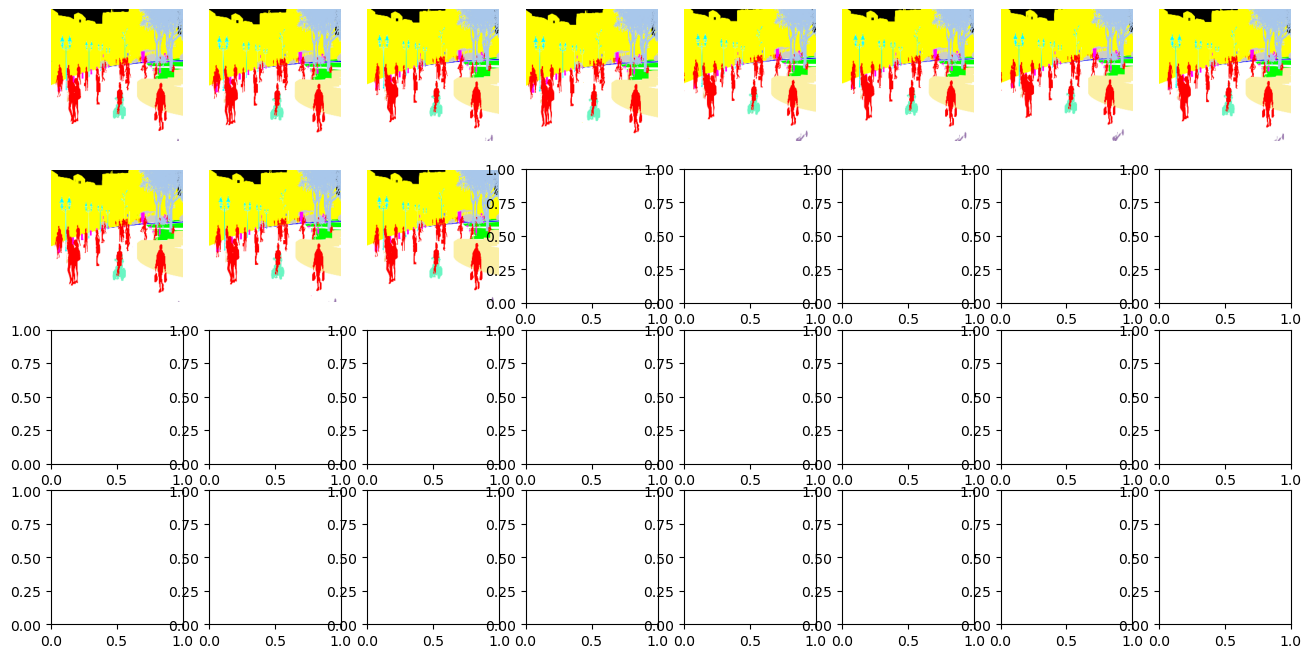

2025-01-08 10:10:59.616215: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
# ImageDataGenerator está OBSOLETO
# from keras.src.legacy.preprocessing.image import ImageDataGenerator

# Devo usar "image_dataset_from_directory" no lugar do ImageDataGenerator.
# A ideia é carregar o conjunto de dados por essa função e tratar o aumento de dados na sequência do programa.

import tensorflow as tf
from tensorflow import keras

# Carrega o dataset de imagens
dataset = keras.utils.image_dataset_from_directory(
    "/media/renato/Data/PIBIC/Dataset",
    # labels="inferred",
    labels=None,
    # label_mode="int",
    label_mode=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=42
)

# Inspeciona o dataset
print("Formato do dataset:", dataset.element_spec)
# print("Número de classes:", len(dataset.class_names))
print("Nomes das classes:", dataset.class_names)

# Visualiza algumas imagens
import matplotlib.pyplot as plt

# for images, labels in dataset.take(1):
for images in dataset.take(1):
    fig, axes = plt.subplots(4, 8, figsize=(16, 8))
    # for i, ax in enumerate(axes.flat):
    for i, ax in enumerate(axes.flat[:len(images)]):
        # ax.imshow(images[i])
        ax.imshow(images[i].numpy().astype("uint8"))
        ax.axis("off")
        # ax.set_title(dataset.class_names[labels[i]])
    plt.show()

